# TRANSFER LEARNING

Authors: Valentina Staneva & Joseph Hellerstein & Claude

This notebook is built on these sources:

* [*Tensorflow Classification Tutorial*](https://www.tensorflow.org/tutorials/images/classification)

* [*Transfer Learning with VGG16 and Keras*](https://towardsdatascience.com/transfer-learning-with-vgg16-and-keras-50ea161580b4),  Medium Blog Post by Gabriel Cassimiro

* [*Tensorflow Transfer Learning Tutorial*](https://www.tensorflow.org/tutorials/images/transfer_learning)

*  https://www.slideshare.net/xavigiro/transfer-learning-d2l4-insightdcu-machine-learning-workshop-2017

## Summary of Transfer Learning

Transfer learning is the practice of taking a model that was trained on one task and reusing it — fully or partially — as the starting point for a different task, rather than training from scratch.

### The Core Idea

When a CNN like VGG16 is trained on ImageNet, its convolutional layers learn general-purpose visual features that are useful far beyond ImageNet itself:

- **Early layers** learn low-level features: edges, corners, color gradients
- **Middle layers** learn mid-level features: textures, patterns, simple shapes
- **Later layers** learn high-level features: eyes, wheels, fur — things specific to the original task

These features turn out to be broadly useful for *any* image recognition task. Rather than relearning them from scratch, transfer learning lets you borrow them.


<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/transfer_learning.png" width="750">

### Why It Works Well

- **Less data needed**: the conv base already knows how to see; you only need enough data to teach the new head your specific classes
- **Faster training**: you're only updating a small fraction of parameters
- **Better results**: especially when your dataset is small, starting from strong pretrained weights almost always outperforms training from scratch

### Transfer Learning & Software Engineering

Transfer learning promotes reuse, reproducibility, and resource efficiency.

## Setup

Import TensorFlow and other necessary libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import PIL
import tensorflow as tf
import datetime

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
import tensorflow.keras.datasets as tfkds
import tensorflow_datasets as tfds
from tensorflow.keras.applications.vgg16 import VGG16
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
import importlib_resources

In [ ]:
# set random seed
# tf.keras.utils.set_random_seed(123)

In [ ]:
# set random seed
# tf.keras.utils.set_random_seed(123)
# tf.random.set_seed(123)

## Flowers Dataset

This tutorial uses a [dataset](https://www.tensorflow.org/datasets/catalog/tf_flowers) of about 3,700 photos of flowers. The dataset contains five types of flowers:

```
  daisy
  dandelion
  roses
  sunflowers
  tulips
```

The goal is to build a classifier which predicts the type of flowers in new images.

The dataset is part of a collection of [datasets](https://www.tensorflow.org/datasets) in the `tensorflow` library which can be directly loaded.

In [ ]:
# downloading images
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir).with_suffix('')
print(data_dir)

image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

In [ ]:
ls /root/.keras/datasets/flower_photos_extracted/flower_photos

In [ ]:
# the images are arranged in folders with their names
list(os.walk(data_dir))[0]

In [ ]:
# looking at a few tulips
tulips = list(sorted(data_dir.glob('flower_photos/tulips/*')))
#print(tulips)
PIL.Image.open(str(tulips[0]))

In [ ]:
PIL.Image.open(str(tulips[1]))

#### Images are not the same size!

The images in the dataset are not the same size so we will resize them so that it is easier to put them in an array and process them efficiently. We fix the weight and height to be 150. This resizing can be achieved automatically while reading the data with the `tf.keras.utils.image_dataset_from_directory` function and setting the image size.

In [ ]:
HEIGHT = 150
WIDTH = 150

In [ ]:
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir / "flower_photos",
  validation_split=0.2,
  subset="both",
  labels="inferred",
  label_mode="categorical",
  seed=123,
  image_size=(HEIGHT, WIDTH),
)

**Note:** if resizing images in your dataset, you need to select an approach which does not distort substantially your data. The `tf.keras.utils.image_dataset_from_directory` function has some other options such as cropping or padding to aspect ratio.





### Hold Out Test Set
Not we set aside 20% for a test set which we will NOT use in model training and selection. It is easy to overtune the model performance to the specific test we have selected and because we have no more "unseen" data to test on our measures of performance may be skewed. We will only use the test set in the end to evaluate the performance on "unseen" data.

In [ ]:
# convert to numpy arrays
train_images, train_labels = zip(*list(train_ds.unbatch()))
train_images = np.array(train_images)
train_labels = np.array(train_labels)

In [ ]:
list(train_ds.unbatch())[1][1]

In [ ]:
print(train_images.shape)
print(train_labels.shape)

We loaded the labels in a categorical format, but we also need the class names. These correspond to the directory names in alphabetical order.

In [ ]:
class_names = ["daisy", "dandelion", "roses", "sunflowers","tulips"]
num_classes = len(class_names)

Let's see the distribution of the classes:

In [ ]:
plt.bar(class_names, train_labels.sum(axis=0))

### Visualize the data



In [ ]:
plt.rcParams["figure.figsize"] = [30, 15]
plt.rcParams["figure.autolayout"] = True

counter = 0
for image, label in zip(train_images, train_labels):
  plt.subplot(2, 5, counter+1)
  plt.imshow(image.astype("uint8"))
  label_name = class_names[np.where(label==1)[0][0]]
  plt.title('Label {}'.format(label_name))
  counter += 1
  if counter == 10:
    break

### Rescale the data

The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network; in general you should seek to make your input values small.

We can rescale values to be in the `[0, 1]` range by using `tf.keras.layers.Rescaling` in the model definition itself.

In [ ]:
layers.Rescaling(1./255)

## CNN Model

We first build a model for classifying flowers to provide a foundation for transfer learning. Some specifics of the model:
* Convolutional layers to find image features
* Dropouts to create a more robust model (and avoid fitting to noise)
* Data augmentation to handle different orientations of pictures

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=train_images[0,:,:,:].shape),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

Data augmentation provides a way to automatically extend the data by having the same image in different rotations.

In [ ]:
plt.rcParams["figure.figsize"] = [30, 15]
plt.rcParams["figure.autolayout"] = True

counter = 0
for image, label in zip(train_images, train_labels):
    plt.subplot(2, 4, counter+1); counter += 1
    plt.imshow(data_augmentation(np.reshape(image, (1, HEIGHT, WIDTH, 3))).cpu().numpy().astype('uint8').squeeze())
    plt.subplot(2, 4, counter+1); counter += 1
    plt.imshow(np.reshape(image, (1, HEIGHT, WIDTH, 3)).astype('uint8').squeeze())
    label_name = class_names[np.where(label==1)[0][0]]
    plt.title('Label {}'.format(label_name))
    if counter == 8:
        break

In [ ]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),

  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.4),

  layers.Dense(num_classes, name="outputs", activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
%%time
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
epochs=50
history = model.fit(
  train_images,
  train_labels,
  validation_split=0.2,
  epochs=epochs,
  batch_size=32,
  callbacks=[es]
)

We observe that:
* training accuracy is ~.76
* validation accuracy is ~.73

In [ ]:
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.autolayout"] = True

In [ ]:
# accuracy metrics at each iteration are stored in the history variable
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(history.history['loss'])+1)

# Loss
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss: Data Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Accuracy
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy: Data Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

The training and validation behavior start to look more similar!

**Warning!** When doing data augmentation make sure augmented derivatives from the same image do not appear both in your train and validation datasets!

**Exercise:** Change some of the random transformation parameters and check if there is difference in performance.

**Exercise:** What other data augmentation techniques can be useful for this problem? Check if they are provided in [Keras](https://keras.io/api/layers/preprocessing_layers/image_augmentation/).

## Imagenet Model (VGG16)

### VGG16 is a classic deep convolutional neural network developed by the Visual Geometry Group at Oxford University in 2014, and published in the paper *"Very Deep Convolutional Networks for Large-Scale Image Recognition"* by Simonyan and Zisserma. It was a top performer in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2014.

### Design Philosophy

The key insight of VGG16 was simplicity and depth: instead of using large kernels (like the 11×11 and 5×5 filters in earlier AlexNet), it stacks many small **3×3 Conv2D layers** with `padding='same'`, which:
- Keeps the architecture uniform and easy to reason about
- Uses fewer parameters than larger kernels while achieving the same receptive field
- Adds more non-linearity (more ReLU activations) which increases expressive power

The "16" in VGG16 refers to the 16 layers that have trainable parameters (13 conv + 3 dense).

<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/vgg16.png" width="750">

### Architecture

| Block | Layers | Output Shape |
|---|---|---|
| Input | — | `(224, 224, 3)` |
| Block 1 | Conv2D(64) × 2, MaxPool | `(112, 112, 64)` |
| Block 2 | Conv2D(128) × 2, MaxPool | `(56, 56, 128)` |
| Block 3 | Conv2D(256) × 3, MaxPool | `(28, 28, 256)` |
| Block 4 | Conv2D(512) × 3, MaxPool | `(14, 14, 512)` |
| Block 5 | Conv2D(512) × 3, MaxPool | `(7, 7, 512)` |
| — | Flatten | `(25088,)` |
| — | Dense(4096), ReLU | `(4096,)` |
| — | Dense(4096), ReLU | `(4096,)` |
| — | Dense(1000), Softmax | `(1000,)` |

All Conv2D layers use `kernel_size=3`, `padding='same'`, and `activation='relu'`. All MaxPooling layers use `pool_size=(2,2)`, which is why spatial dims halve at each block. The final Dense(1000) corresponds to the 1000 ImageNet classes.

### Parameter Count

VGG16 has approximately **138 million parameters**, which was large even by 2014 standards. The striking thing is how lopsided the distribution is:

| Section | Params | % of total |
|---|---|---|
| All 13 Conv2D layers | ~15M | ~11% |
| Dense(4096) × 2 + Dense(1000) | ~123M | ~89% |

The two Dense(4096) layers alone account for the vast majority of parameters, which is why modern architectures (ResNet, EfficientNet, etc.) tend to use Global Average Pooling before the classifier head instead of Flatten → Dense, dramatically cutting parameter counts.

### Loading VGG16 in Keras

Keras includes VGG16 as a built-in model, optionally with ImageNet pretrained weights:

```python

model = VGG16(
    weights='imagenet',   # or None for random init
    include_top=True,     # False drops the Dense layers, useful for transfer learning
    input_shape=(224, 224, 3)
)

model.summary()
```

### Strengths and Weaknesses

| Strengths | Weaknesses |
|---|---|
| Simple, uniform architecture — easy to understand | 138M params — very heavy to train and store |
| Strong pretrained features, great for transfer learning | Slow inference compared to modern nets |
| Influenced almost all subsequent CNN designs | No skip connections — deep gradient flow can be difficult |
| Well studied and documented | Largely superseded by ResNet, EfficientNet, etc. |

Despite its age, VGG16 remains widely used as a **feature extractor** in transfer learning, since its convolutional blocks produce rich, general-purpose image features that transfer well to new tasks.

## Transfer Learning Using VGG16

Convolutional Neural Networks can be good feature extractors, i.e. a model trained on one dataset can turn out to be good at extracting useful features from another dataset. This allows deep learning methods to leverage large training sets and be able to generalize to situations where training data can be scarce.

* predict with a pretrained model on new data (zero-shot learning)
* extract features with a pretrained model and use them to train a shallow classifier on new data
* fine-tune the trained model to the new data by training with a small learning rate
* retrain the full model using the pre-trained model weights as initializers

As usual, we will have to evaluate the performance!

![TransferLearning](https://drive.google.com/uc?export=view&id=1QF9-eDrTkMouYJdU4k1qCklT3pLCI61u)

image src = https://www.slideshare.net/xavigiro/transfer-learning-d2l4-insightdcu-machine-learning-workshop-2017

<img src="https://i.stack.imgur.com/RTKux.png" width="750">

### Frozen Pretrained Weights


Procedure:

* load and initialize a pretrained model
* remove the top layer
* freeze the weights of the pretrained model
* add a top layer(s) linking to our classes
* train the model

We will use a rather popular architecture VGG16 trained on the huge [Imagenet](https://www.image-net.org/) Dataset.


In [ ]:
## Loading VGG16 model
pretrained_model = VGG16(weights="imagenet", include_top=False, input_shape=(HEIGHT, WIDTH, 3))
pretrained_model.trainable = False ## Not trainable weights

In [ ]:
pretrained_model.summary()

Pretrained models have certain expectations of how the data should look like so that it can be used in the model. They have a corresponding [`preprocess_input`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/preprocess_input) model. Make sure you read on the operations in the preprocessing so that it makes sense for your data.

In [ ]:
preprocess_input(train_images.copy()).shape

**Warning!** The `preprocess_input` function changes the input **in-place** hence we need to pass a copy of the images.  

In [ ]:
flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(128, activation='relu')
prediction_layer = layers.Dense(5, activation='softmax')


model = models.Sequential([
    pretrained_model,
    flatten_layer,
    dense_layer_1,
    prediction_layer
])

In [ ]:
model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)

In [ ]:
%%time
epochs=50
history = model.fit(
  preprocess_input(train_images.copy()),
  train_labels,
  validation_split=0.2,
  epochs=epochs,
  batch_size=32,
  callbacks=[es]
)

* training accuracy is very high again: ~0.98
* validation accuracy is also high: 0.79

In [ ]:
# accuracy metrics at each iteration are stored in the history variable
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(history.history['loss'])+1)

# Loss
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss: Frozen VGG')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Accuracy
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy: Frozen VGG')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

### Fine-Tune Pretrained Weights

Fine Tuning:
* Set the pretrained model to trainable (or some of its layers)
* Compile the model again
* Retrain with a small learning rate (0.0001)


In [ ]:
pretrained_model.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [ ]:
model.summary()

In [ ]:
%%time
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
epochs=50
history_fine = model.fit(
  preprocess_input(train_images.copy()),
  train_labels,
  validation_split=0.2,
  epochs=epochs,
  batch_size=32,
  callbacks=[es]
)

In [ ]:
# accuracy metrics at each iteration are stored in the history variable

acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

In [ ]:
epochs_range = range(1, len(history.history['loss'])+ len(history_fine.history['accuracy'])+1)
print(epochs_range)

# Loss
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x = len(history.history['loss'])+1, color = 'g',)
plt.text(len(history.history['loss'])+1,2,'Fine-Tuning Starts',rotation=90, color='g')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss: Fine-tuned VGG')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Accuracy
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x = len(history.history['loss'])+1, color = 'g')
plt.text(len(history.history['loss'])+1, 0.88,'Fine-Tuning Starts',rotation=90, color='g')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy: Fine-tuned VGG')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

**Exercise:** Retrain full model starting from the imagenet weights (making all weights trainable).

**Exercise:** Retrain the last 10 layers of the pretrained model + the top layer.
**Hint:** Use a loop to unfreeze layers.

Pretrained models can be found:
* within the [keras library](https://keras.io/api/applications/)
* on [tensorflow(kaggle) hub](https://www.tensorflow.org/hub)
* [HuggingFace](https://huggingface.co/models)
* domain-specific challenges
* colleagues


## MNIST Fashion Data

In [22]:
(x_train, y_train), (x_test, y_test) = tfkds.cifar100.load_data()
_, info = tfds.load('cifar100', with_info=True)
fine_labels = np.array(info.features['label'].names)

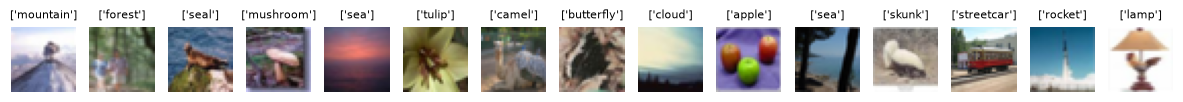

In [31]:
def plotImage(x_arr: np.ndarray, y_arr: np.ndarray):
    num_fig = x_arr.shape[0]
    _, axes = plt.subplots(1, num_fig, figsize=(15,15))
    for idx in range(num_fig):
        ax = axes[idx]
        ax.imshow(x_arr[idx, :, :, :].astype("uint8"))
        ax.axis('off')              # optional: hides the axis ticks
        text = y_arr[idx]
        if not isinstance(text, str):
            test = text[0]
        ax.set_title(text, fontsize=8)
    plt.show()

# TESTS
num_pic = 15
plotImage(x_test[0:num_pic, :, :], fine_labels[y_test[0:num_pic]])

### Prepare data

There's one big mismatch to address upfront: VGG16 expects (224, 224, 3) RGB input, but MNIST images are (32, 32, 3). You have to handle both issues — size and channels.

In [15]:
NEW_HEIGHT = 32
NEW_WIDTH = 32

x_train_nrml = x_train / 255.0
x_test_nrml  = x_test  / 255.0

### Build the model

In [16]:
# Load VGG16 without the top Dense layers, with ImageNet weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(NEW_HEIGHT, NEW_WIDTH, 3))
base_model.trainable = False  # freeze the convolutional base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')   # 10 classes for digits 0-9
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Compile and Train

We use early stopping to detect when accuracy is not improving significantly.

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use this when labels are integers
    metrics=['accuracy']
)
es = EarlyStopping(monitor='accuracy', mode='max', patience=2,  restore_best_weights=True, min_delta=0.01)
history = model.fit(
    x_train_nrml, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.0566 - loss: 0.1276 - val_accuracy: 0.0614 - val_loss: 0.1031
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0672 - loss: 0.0972 - val_accuracy: 0.0636 - val_loss: 0.0961
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0707 - loss: 0.0853 - val_accuracy: 0.0644 - val_loss: 0.0937
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0745 - loss: 0.0768 - val_accuracy: 0.0644 - val_loss: 0.0912


### Assessing the results

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


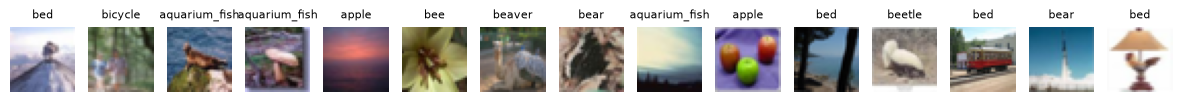

In [32]:
# Returns probabilities for each class, shape (num_samples, num_classes)
y_pred_probs = model.predict(x_test_nrml)

# Convert probabilities to class labels by taking the argmax
y_pred = np.argmax(y_pred_probs, axis=1)

# Plot the result
num_pic = 15
plotImage(x_test[0:num_pic, :, :], fine_labels[y_pred[0:num_pic]])

In [30]:
fine_labels[y_pred[0:num_pic]]

array(['bed', 'bicycle', 'aquarium_fish', 'aquarium_fish', 'apple', 'bee',
       'beaver', 'bear', 'aquarium_fish', 'apple', 'bed', 'beetle', 'bed',
       'bear', 'bed'], dtype='<U13')

## Save Model


We are saving the model architecture, weights, and training configuration. We can restart training from it!

In [ ]:
model.save("flowers_model.keras")

## Too Many Experiments!

[TensorBoard](https://www.tensorflow.org/tensorboard) is a tool to visualize experiment performance. It can also visualize results during training. There are many other options but tensorboard is open source and can run locally and integrates with notebooks.

In [ ]:
# add this additional callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

To run tensorboard in a notebook:

In [ ]:
%load_ext tensorboard

%tensorboard --logdir logs/fit

## Hyperparameter Tuning

We can see how there are many parameters that can be tuned in a NN model:

* network parameters
* optimization parameters


A natural question is whether we can automate the process of testing different values. There are several approaches to that:

* Grid Search
* Random Search
* Bayesian Optimization

There are also tools to achieve that in Keras:

[keras tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner)

[HParams Dashboard](https://www.tensorflow.org/tensorboard/hyperparameter_tuning_with_hparams)

**Warning!** Automatic hyperparameter search can be very prone to overtuning. It can be useful when there is a large amount of training data (which will also allow for plenty validation data). However, when large training datasets are available, the models may work well without too much tuning.

## Predict On New data

Use the selected model to classify an image that wasn't included in the training or validation sets.

Note: Data augmentation and dropout layers are inactive at inference time.

In [ ]:
# convert to numpy arrays
test_images, test_labels = zip(*list(test_ds.unbatch()))
test_images = np.array(test_images)
test_labels = np.array(test_labels)

In [ ]:
predictions = model.predict(test_images)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

In [ ]:
plt.imshow(test_images[0,:,:,:]/255.)

In [ ]:
# once you are ready to evaluate on the test data you can run this command
# Warning: run this once to report the results, do not tune/select the model based on the test data!

# loss, acc = model.evaluate(test_images, test_labels)

## Notes

1. Refine example of transfer learning with fashion. How get good performance?
2. Get MNIST example back so see data transformations.